# Test del BmodeSimulator

Importa el simulador y grafica un mapa de ejemplo.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import sys, os
%matplotlib inline
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), '..'))
from cmb.simulators import BmodeSimulator128

shape: (128, 128), mean: -0.1234, rms: 3.5810


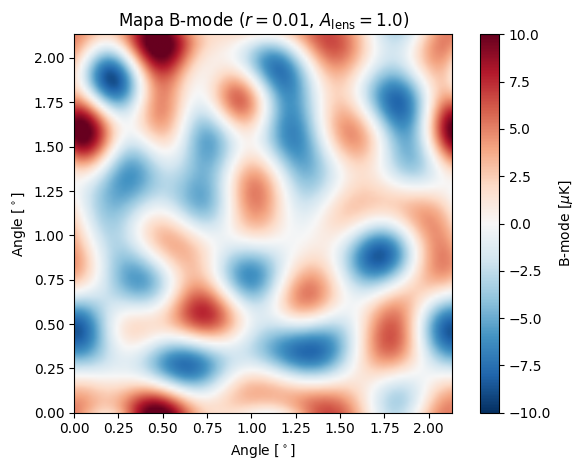

In [16]:
sim = BmodeSimulator128()

theta = torch.tensor([0.01, 1.0])
x = sim.simulate(theta, seed=42)

N = 128
pix_size = 1.0
Xw = N * pix_size / 60.0

mapa = x.numpy().reshape(N, N)

print(f"shape: {mapa.shape}, mean: {mapa.mean():.4f}, rms: {mapa.std():.4f}")

plt.imshow(mapa, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
           vmin=-10, vmax=10, extent=[0, Xw, 0, Xw])
plt.colorbar(label=r'B-mode [$\mu$K]')
plt.xlabel(r'Angle $[^\circ]$')
plt.ylabel(r'Angle $[^\circ]$')
plt.title(r'Mapa B-mode ($r=0.01$, $A_{\mathrm{lens}}=1.0$)')
plt.tight_layout()
plt.show()

## Batch de sims

In [17]:
theta_batch = torch.tensor([[0.0, 1.0],
                            [0.7, 1.0],
                            [0.14, 1.0],
                            [0.2, 1.0]])
x_batch = sim(theta_batch, show_progress=True)
print(f"batch shape: {x_batch.shape}")

Simulating: 100%|██████████| 4/4 [00:00<00:00, 34.21it/s]

batch shape: torch.Size([4, 16384])


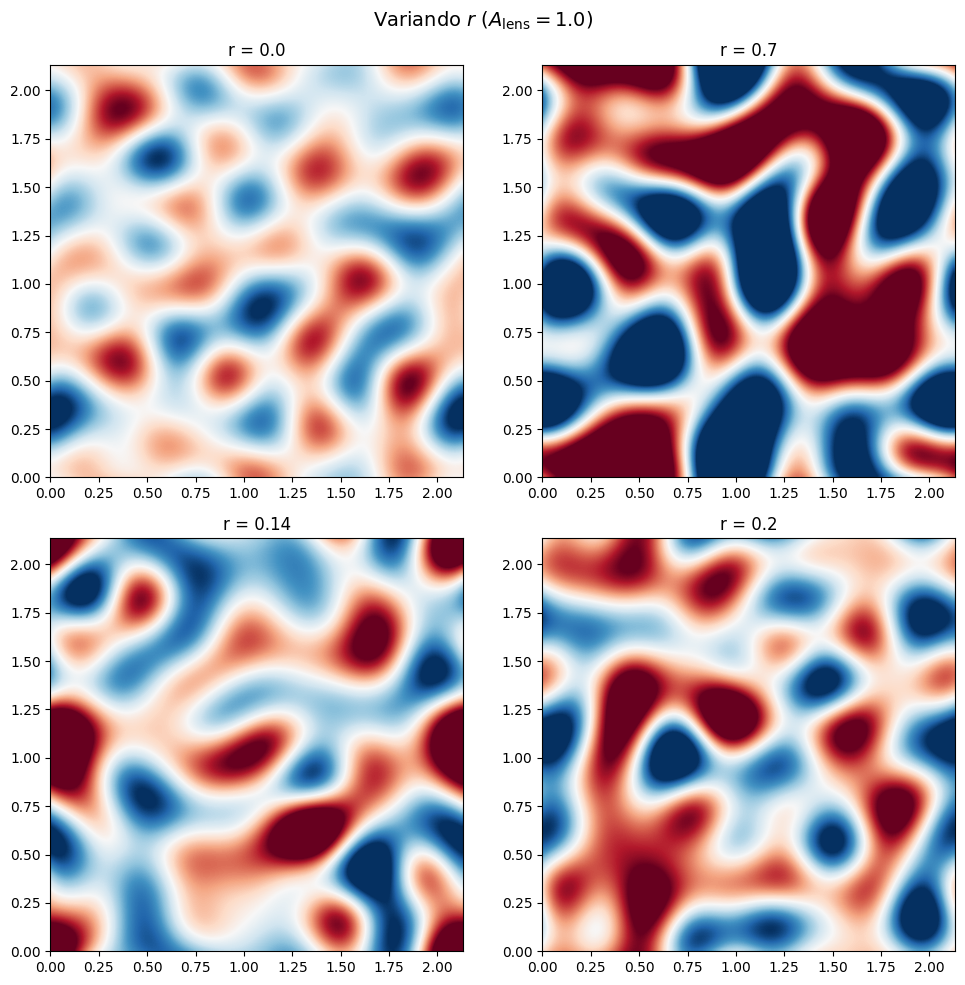

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
r_vals = [0.0, 0.7, 0.14, 0.2]
for ax, r_val, x_row in zip(axes.flat, r_vals, x_batch):
    m = x_row.numpy().reshape(N, N)
    ax.imshow(m, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
              vmin=-10, vmax=10, extent=[0, Xw, 0, Xw])
    ax.set_title(f'r = {r_val}')
plt.suptitle(r'Variando $r$ ($A_{\mathrm{lens}} = 1.0$)', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
theta_batch = torch.tensor([[0.05, 0.0],
                            [0.05, 1.0],
                            [0.05, 2.0],
                            [0.05, 3.0]])
x_batch = sim(theta_batch, show_progress=True)
print(f"batch shape: {x_batch.shape}")

Simulating: 100%|██████████| 4/4 [00:00<00:00, 34.17it/s]

batch shape: torch.Size([4, 16384])


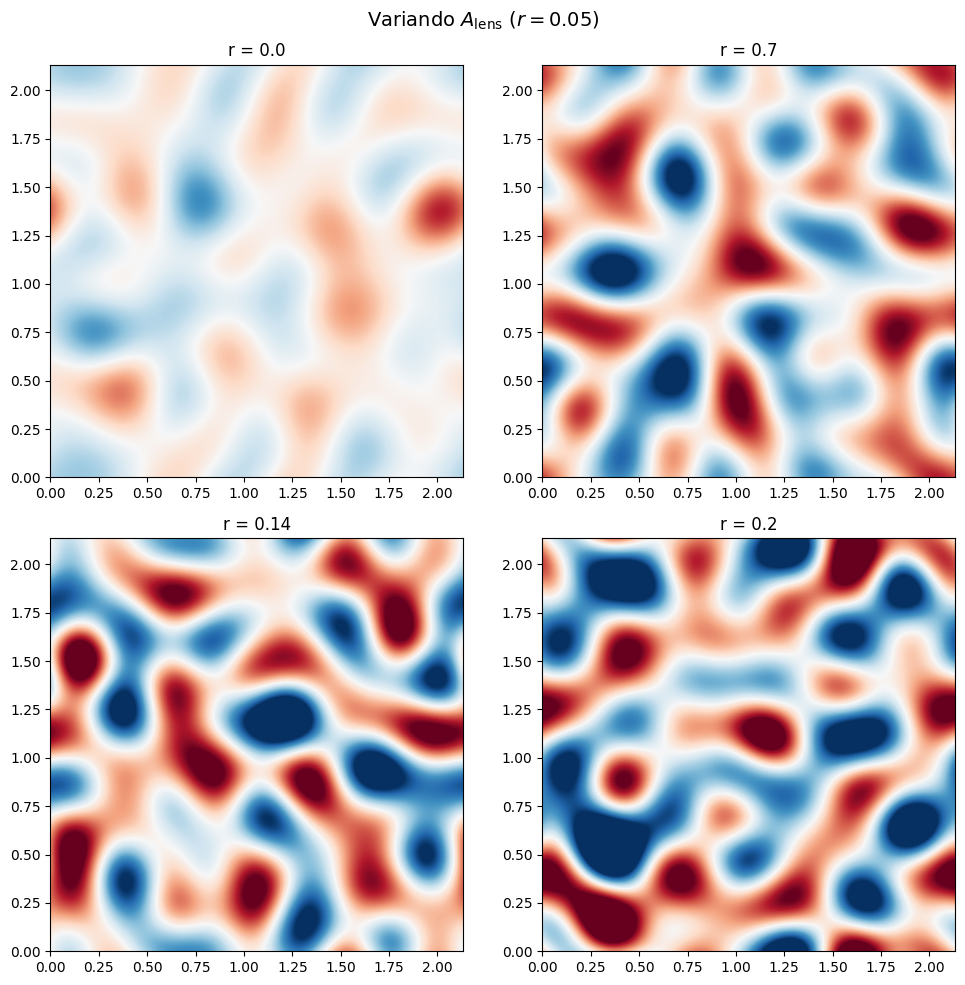

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
r_vals = [0.0, 0.7, 0.14, 0.2]
for ax, r_val, x_row in zip(axes.flat, r_vals, x_batch):
    m = x_row.numpy().reshape(N, N)
    ax.imshow(m, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
              vmin=-10, vmax=10, extent=[0, Xw, 0, Xw])
    ax.set_title(f'r = {r_val}')
plt.suptitle(r'Variando $A_{\mathrm{lens}}$ ($r = 0.05$)', fontsize=14)
plt.tight_layout()
plt.show()

## simulate_obs con seed fija

Usando `simulate_obs` con seed determinada para reproducibilidad.

x_o shape: torch.Size([1, 16384])


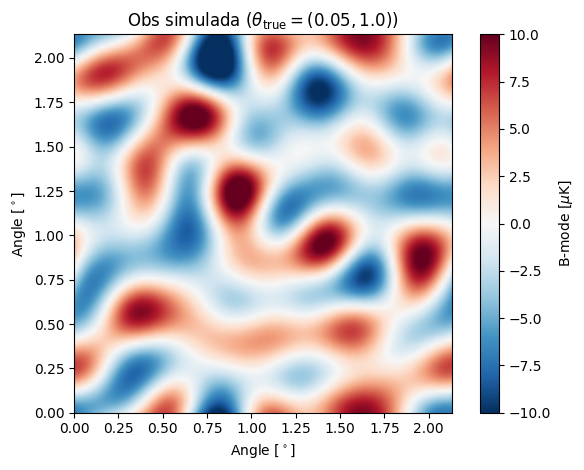

In [21]:
from zbi.pipeline import simulate_obs

x_o = simulate_obs(sim, theta_true=(0.05, 1.0), seed=122)
print(f"x_o shape: {x_o.shape}")

mapa_o = x_o.numpy().reshape(N, N)
plt.imshow(mapa_o, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
           vmin=-10, vmax=10, extent=[0, Xw, 0, Xw])
plt.colorbar(label=r'B-mode [$\mu$K]')
plt.xlabel(r'Angle $[^\circ]$')
plt.ylabel(r'Angle $[^\circ]$')
plt.title(r'Obs simulada ($\theta_{\mathrm{true}} = (0.05, 1.0)$)')
plt.tight_layout()
plt.show()